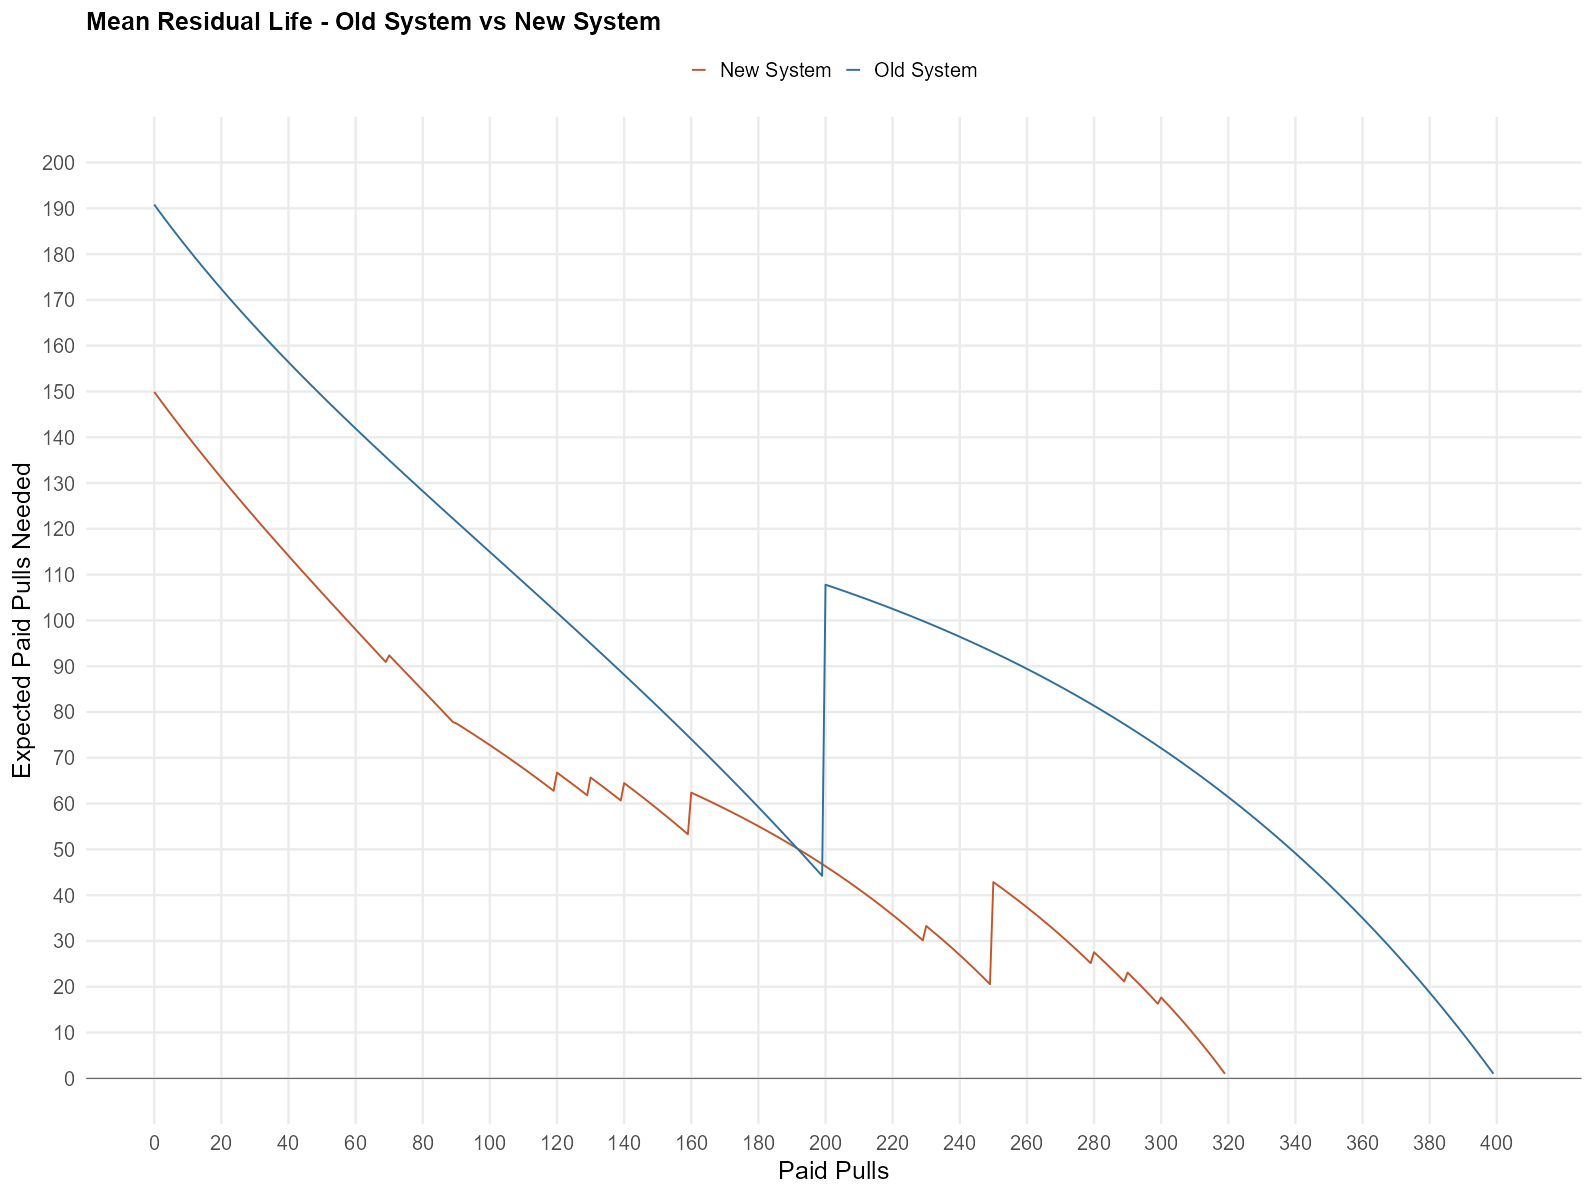

In [16]:
library(ggplot2)

p  <- 0.007
q  <- 1 - p
r  <- 21296 / 1e8   #off-rate chance (approximation from rate info when I opened BA)
p1 <- p + r         
n  <- 1 - p1

#Old System
t1 <- numeric(401)
tt <- 2:199;   t1[tt + 1] <- p * p1 / r * (q^(tt - 1) - n^(tt - 1))
t1[201]                   <- p1 / r * (q^199 - n^199) + p1 * n^199
tt <- 201:399; t1[tt + 1] <- n^200 * q^(tt - 201) * p
t1[401]                   <- n^200 * q^199

#New System
h <- replace(rep(p, 199), 100, 0.5)
x <- c(h, 1) * cumprod(c(1, 1 - h))
w <- cumprod(c(1, (1 - h - r) / (1 - h)))
y <- c(0, x * (1 - w), rep(0, 200))
y[3:401] <- y[3:401] + convolve(x * w, rev(x), type = "open")

#Milestone 10-pull tickets
ms   <- c(70, 130, 150, 170, 270, 330, 350, 370)
tot  <- 0:400
paid <- tot - sapply(tot, function(t) sum(pmin(pmax(t - ms, 0), 10)))
t2   <- as.vector(tapply(y, paid, sum))

#Mean Residual Life Calc
mrl <- function(pmf) {
  S <- 1 - cumsum(pmf)
  m <- rev(cumsum(rev(S))) / S
  m[S < 1e-12] <- NA
  m
}

#Plot
df <- rbind(
  data.frame(k = 0:400,                mrl = mrl(t1), system = "Old System"),
  data.frame(k = 0:(length(t2) - 1),   mrl = mrl(t2), system = "New System")
)
df <- df[!is.na(df$mrl), ]

ggplot(df, aes(k, mrl, colour = system)) +
  geom_hline(yintercept = 0, colour = "grey25", linewidth = 0.4) +
  geom_line(linewidth = 0.9) +
  scale_x_continuous(breaks = seq(0, 400, 20), limits = c(0, 405)) +
  scale_y_continuous(breaks = seq(0, 200, 10), limits = c(0, 200)) +
  scale_colour_manual(values = c("Old System" = "#2E6F9E", "New System" = "#C4552B"), name = NULL) +
  labs(title = "Mean Residual Life - Old System vs New System", x = "Paid Pulls", y = "Expected Paid Pulls Needed") +
  theme_minimal(base_size = 25) +
  theme(plot.title = element_text(face = "bold", size = 25),
        legend.position = "top",
        panel.grid.minor = element_blank())

*What is this?*  
This plot is showing the results from computing E[X - p | X > p], where X is your random variable and p is the number of paid pulls used. What it is describing is the expected number of pulls needed to finish, given I have already pulled so many times.  
As an example, if you have already pulled 150 paid pulls, the plot at that point is showing the expected number of pulls required to finish from that point on (finishing in this context is getting 2 rate ups).  

*Notable Results*  
The first 50/50 does not change your expectation at all if you win or lose.  
In the old system, if you get to 200 pulls without a rate up (~25% chance) your expected number of pulls needed to finish spikes massively to 108.  
All the small jumps in expectation for the new system are at the milestone 10-pull tickets and aat the 50/50 at 250.  
